In [111]:
# Loading MNIST dataset
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import platform
import torch.nn.functional as F

# Apple Silicon / macOS: use Metal (MPS), else CPU.
_is_mac = platform.system() == "Darwin"
if _is_mac and torch.backends.mps.is_available():
    device = torch.device("mps")

else:
    device = torch.device("cpu")
print("Using device:", device)

# Load the MNIST dataset
mnist_train_data = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
# Keep images as float32 on-device once (avoid per-step casting)
X_train = mnist_train_data.data.to(device=device, dtype=torch.float32) / 255.0
y_train = mnist_train_data.targets.to(device)
mnist_test_data = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transforms.ToTensor())
X_test = mnist_test_data.data.to(device=device, dtype=torch.float32) / 255.0
y_test = mnist_test_data.targets.to(device)

print(X_train.shape)

def plot_image(x, y):
    plt.imshow(x.detach().cpu().numpy(), cmap="gray", vmin=0, vmax=255)
    plt.title(f"label: {y.item()}")
    plt.axis("off")
    plt.show()

# Compute the score of the model (vectorized; avoid `if tensor == tensor` in a Python loop)
def score(ys_pred, ys):
    return (ys_pred == ys).float().mean().item()


Using device: mps
torch.Size([60000, 28, 28])


In [318]:
# Creating the CNN model
class CNN:
    def __init__(self, Xs, ys):
        self.Xs = Xs
        self.ys = ys
        self.filter_size_1 = 3
        self.filter_size_2 = 2
        self.filter_size_3 = 2
        self.num_filters_1 = 64
        self.num_filters_2 = 32
        self.padding = 0
        self.stride = 1

        device, dtype = Xs.device, torch.float32
        h_in, w_in = int(Xs.shape[1]), int(Xs.shape[2])
        h_conv_1 = (h_in + 2 * self.padding - self.filter_size_1) // self.stride + 1
        w_conv_1 = (w_in + 2 * self.padding - self.filter_size_1) // self.stride + 1
        h_pool_1 = h_conv_1 // 2 
        w_pool_1 = w_conv_1 // 2 

        h_conv_2 = (h_pool_1 + 2 * self.padding - self.filter_size_2) // self.stride + 1
        w_conv_2 = (w_pool_1 + 2 * self.padding - self.filter_size_2) // self.stride + 1
        h_pool_2 = h_conv_2 // 2 
        w_pool_2 = w_conv_2 // 2 
        
        flat_dim = self.num_filters_2 * h_pool_2 * w_pool_2

        # Convolutional layer 1
        self.W1 = (
            torch.randn(
                self.num_filters_1,
                self.filter_size_1,
                self.filter_size_1,
                device=device,
                dtype=dtype,
            )
            * 0.05
        ).detach().requires_grad_()
        self.b1 = torch.zeros(self.num_filters_1, device=device, dtype=dtype, requires_grad=True)

        # Convolutional layer 2 
        self.W2 = (
            torch.randn(
                self.num_filters_2,
                self.num_filters_1,
                self.filter_size_2,
                self.filter_size_2,
                device=device,
                dtype=dtype,
            )
            * 0.05
        ).detach().requires_grad_()
        self.b2 = torch.zeros(self.num_filters_2, device=device, dtype=dtype, requires_grad=True)

        # Linear layer 1
        self.W3 = (
            torch.randn(flat_dim, 64, device=device, dtype=dtype) * 0.05
        ).detach().requires_grad_()
        self.b3 = torch.zeros(64, device=device, dtype=dtype, requires_grad=True)

        # Linear layer 2
        self.W4 = (
            torch.randn(64, 10, device=device, dtype=dtype) * 0.05
        ).detach().requires_grad_()
        self.b4 = torch.zeros(10, device=device, dtype=dtype, requires_grad=True)

        self.params = [self.W1, self.b1, self.W2, self.b2, self.W3, self.b3, self.W4, self.b4]

    def train(self, lr, lr_decay=1.0):
        """Plain SGD. Use lr_decay < 1 (e.g. 0.95) to multiply the LR after each epoch."""
        loss_history = []
        batch_size = 1024
        num_epochs = 10
        n = self.Xs.shape[0]
        current_lr = float(lr)
        for _ in range(num_epochs):
            shuffled_indices = torch.randperm(n, device=self.Xs.device)
            for j in range(0, n, batch_size):
                Xs = self.Xs[shuffled_indices[j : j + batch_size]]
                ys = self.ys[shuffled_indices[j : j + batch_size]]

                # Forward pass
                Z = F.conv2d(
                    Xs.unsqueeze(1),
                    self.W1.unsqueeze(1),
                    self.b1,
                    stride=self.stride,
                    padding=self.padding,
                )
                # ReLU activation
                Z = F.relu(Z)
                # Max-pooling layer
                Z = F.max_pool2d(Z, kernel_size=2, stride=2)
                # Convolutional layer 2 (Z is NCHW after conv1+pool — use conv2d)
                Z = F.conv2d(
                    Z,
                    self.W2,
                    self.b2,
                    stride=self.stride,
                    padding=self.padding,
                )
                # ReLU activation
                Z = F.relu(Z)
                # Max-pooling layer
                Z = F.max_pool2d(Z, kernel_size=2, stride=2)
                # Flatten the output
                Z = Z.view(Z.shape[0], -1)
                # Linear layer
                Z = Z @ self.W3 + self.b3
                # ReLU activation
                Z = F.relu(Z)
                # Linear layer 2
                Z = Z @ self.W4 + self.b4
                loss = F.cross_entropy(Z, ys.long())


                # Backward pass
                for p in self.params:
                    p.grad = None
                loss.backward()
                with torch.no_grad():
                    for param in self.params:
                        if param.grad is not None:
                            param -= current_lr * param.grad

            loss_history.append(loss.detach().clamp_min(1e-30).log10().item())
            current_lr *= lr_decay

        plt.figure(figsize=(8, 4))
        plt.plot(loss_history)
        plt.xlabel("Step")
        plt.ylabel("Loss")
        plt.title("Training loss")
        plt.grid(True)
        plt.show()

    def predict(self, Xs):
        with torch.no_grad():
             # Forward pass
            Z = F.conv2d(
                Xs.unsqueeze(1),
                self.W1.unsqueeze(1),
                self.b1,
                stride=self.stride,
                padding=self.padding,
            )
            # ReLU activation
            Z = F.relu(Z)
            # Max-pooling layer
            Z = F.max_pool2d(Z, kernel_size=2, stride=2)
            # Convolutional layer 2
            Z = F.conv2d(
                Z,
                self.W2,
                self.b2,
                stride=self.stride,
                padding=self.padding,
            )
            # ReLU activation   
            Z = F.relu(Z)
            # Max-pooling layer
            Z = F.max_pool2d(Z, kernel_size=2, stride=2)
            # Flatten the output
            Z = Z.view(Z.shape[0], -1)
            # Linear layer
            Z = Z @ self.W3 + self.b3
            # ReLU activation
            Z = F.relu(Z)
            # Linear layer 2
            Z = Z @ self.W4 + self.b4
            
            return Z.argmax(dim=1)

In [319]:
# Create utility function to train the model on the training set and predict on the test set
import time

# Training
def execute(CNN, lr, lr_decay=0.99):
    CNN.train(lr, lr_decay=lr_decay)
    
   
# Prediction
def check(CNN, X_train, y_train, X_test, y_test):
    # Z = CNN.predict(X_test)
    # T = torch.randperm(1000)
    # for i in range(10):
    #     plot_image(X_test[T[i]]*255.0,Z[T[i]])
    with torch.no_grad():
        train_acc = score(CNN.predict(X_train), y_train)
        test_acc = score(CNN.predict(X_test), y_test)
    print(f"Train accuracy (same data as loss): {100 * train_acc:.2f}%")
    print(f"Test accuracy: {100 * test_acc:.2f}%")


In [320]:
# CNN with 2 convolutional layers and 2 linear layers
# First one has 3x3 filters, 10 filters, padding 0, stride 1 
# Second one has 2x2 filters, 10 filters, padding 0, stride 1
# Mini-batch Gradient Descent with learning rate 0.01
SGD = CNN(Xs=X_train, ys=y_train)

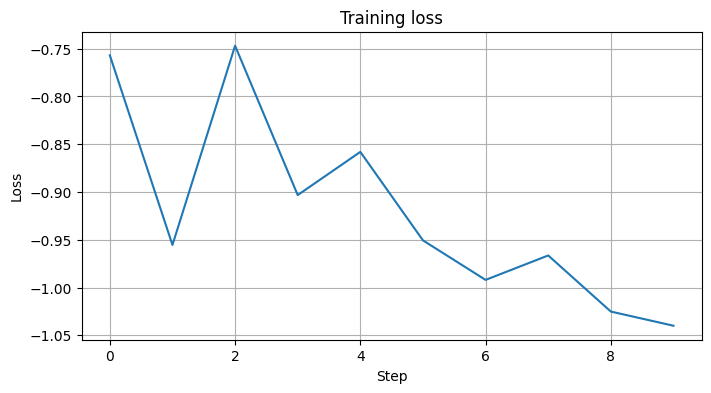

In [322]:
execute(SGD, 0.1)

In [323]:
check(SGD, X_train, y_train, X_test, y_test)



Train accuracy (same data as loss): 82.45%
Test accuracy: 97.35%
